# Trend Detection with HDBSCAN
HDBSCAN clustering on TF-IDF text embeddings to find trending sub-topics within the `trending_topics` dataset.

## 1. Imports & Config

In [1]:
import os
os.makedirs("Results/HDBSCAN", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import hdbscan

from database_util import connect_database

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Load Data from PostgreSQL

In [2]:
conn = connect_database()

cursor = conn.cursor()
cursor.execute("""
    SELECT post_id, text_translated, niche, timestamp_utc, score, num_comments
    FROM final_trendingtopics
    WHERE text_translated IS NOT NULL
      AND TRIM(text_translated) != ''
""")
rows = cursor.fetchall()
cols = [desc[0] for desc in cursor.description]
df = pd.DataFrame(rows, columns=cols)
cursor.close()

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df["score"] = df["score"].fillna(0)
df["num_comments"] = df["num_comments"].fillna(0)
df["engagement"] = df["score"] + df["num_comments"]

print(f"Loaded {len(df):,} rows")
print(df["niche"].value_counts())

Loaded 7,090 rows
niche
movies         1588
worldnews      1518
technology     1417
smartphones    1226
gaming          818
science         523
Name: count, dtype: int64


## 3. Text Vectorisation (TF-IDF → SVD)

In [3]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    stop_words="english"
)
X_tfidf = tfidf.fit_transform(df["text_translated"])
print(f"TF-IDF shape: {X_tfidf.shape}")

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_norm = normalize(X_svd)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

TF-IDF shape: (7090, 8000)
SVD explained variance: 15.04%


## 4. HDBSCAN Clustering
Adjust MIN_CLUSTER_SIZE for clustering

In [4]:
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES      = 5

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

labels      = clusterer.fit_predict(X_norm)
soft_scores = hdbscan.all_points_membership_vectors(clusterer)

df["cluster"]       = labels
df["cluster_prob"]  = clusterer.probabilities_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
noise_pct  = n_noise / len(labels) * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print(f"Clustered posts: {len(df) - n_noise:,}")

if n_clusters > 1:
    mask  = labels != -1
    score = silhouette_score(X_norm[mask], labels[mask], metric="euclidean", sample_size=3000)
    print(f"Silhouette score (excl. noise): {score:.4f}")

print(f"Cluster labels: {sorted(set(labels) - {-1})}")

Clusters found : 24
Noise points   : 4,745 (66.9%)
Clustered posts: 2,345
Silhouette score (excl. noise): 0.2246
Cluster labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 5. Cluster Sizes

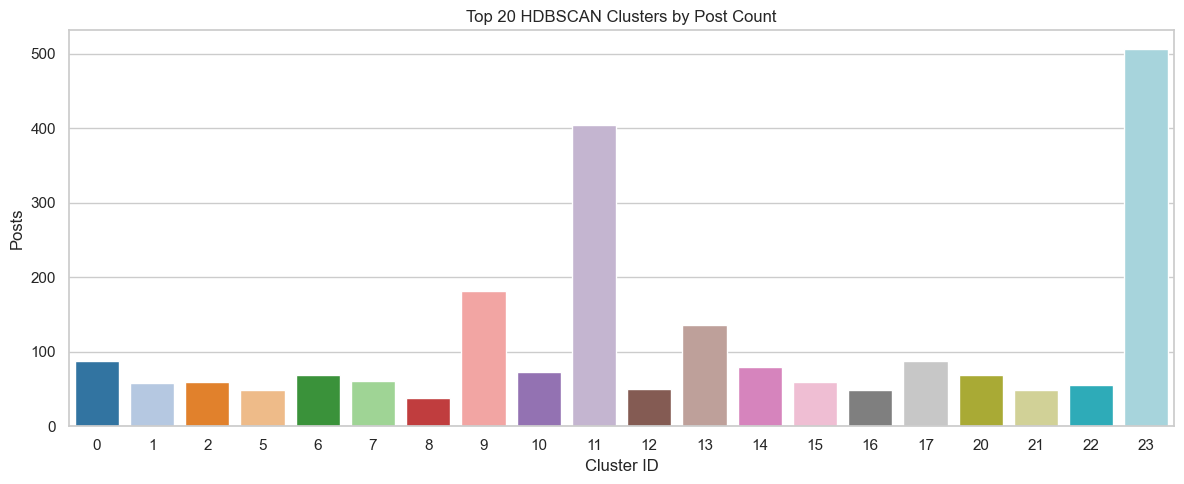

In [5]:
cluster_counts = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_n = min(20, len(cluster_counts))
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",
            hue="cluster", palette="tab20", legend=False, ax=ax)
ax.set_title(f"Top {top_n} HDBSCAN Clusters by Post Count")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
plt.tight_layout()
plt.savefig("Results/HDBSCAN/hdbscan_cluster_sizes.png", bbox_inches="tight")
plt.show()

## 6. Cluster Keywords (Top TF-IDF Terms)

In [6]:
feature_names = tfidf.get_feature_names_out()
TOP_K_WORDS = 8

print("=" * 65)
print(f"{'Cluster':>8}  {'Posts':>6}  Top Keywords")
print("=" * 65)

cluster_keywords = {}
for cid in cluster_counts["cluster"]:
    mask = (df["cluster"] == cid).values
    centroid = X_tfidf[mask].mean(axis=0)
    centroid = np.asarray(centroid).flatten()
    top_idx  = centroid.argsort()[::-1][:TOP_K_WORDS]
    keywords = ", ".join(feature_names[top_idx])
    cluster_keywords[cid] = keywords
    n = mask.sum()
    print(f"{cid:>8}  {n:>6}  {keywords}")

df["cluster_keywords"] = df["cluster"].map(cluster_keywords)

 Cluster   Posts  Top Keywords
      23     506  movie, game, like, movies, just, games, really, time
      11     404  iran, hormuz, strait, strait hormuz, trump, war, iran war, says
       9     181  ukraine, russian, russia, hungary, election, oil, eu, magyar
      13     136  pro, iphone, ultra, 17, s26, iphone 17, pro max, phone
       0      88  social, social media, media, ban, media ban, government, people, addiction
      17      88  ai, startup, generated, ai generated, says, powered, future, revenue
      14      79  phone, good, camera, buy, battery, good camera, looking, best
      10      73  anthropic, claude, mythos, code, model, ai, ai model, anthropic mythos
       6      69  trailer, official, official trailer, official teaser, theaters, teaser, 2026, june
      20      69  study, study finds, finds, associated, risk, analysis, new study, sleep
       7      61  poster, official poster, official, new poster, new, theaters, starring, anniversary
      15      60  dire

## 7. Membership Confidence Distribution

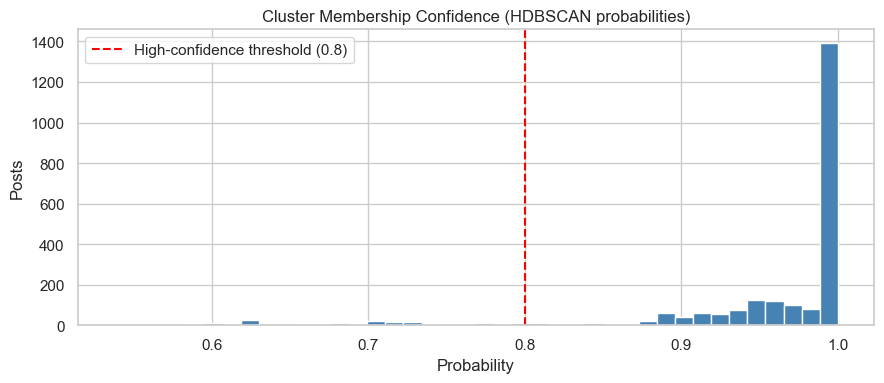

92.5% of clustered posts have confidence ≥ 0.8


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
clustered = df[df["cluster"] != -1]
ax.hist(clustered["cluster_prob"], bins=40, color="steelblue", edgecolor="white")
ax.set_title("Cluster Membership Confidence (HDBSCAN probabilities)")
ax.set_xlabel("Probability")
ax.set_ylabel("Posts")
ax.axvline(0.8, color="red", linestyle="--", label="High-confidence threshold (0.8)")
ax.legend()
plt.tight_layout()
plt.savefig("Results/HDBSCAN/hdbscan_confidence.png", bbox_inches="tight")
plt.show()

high_conf = (clustered["cluster_prob"] >= 0.8).mean() * 100
print(f"{high_conf:.1f}% of clustered posts have confidence ≥ 0.8")

## 8. Topic Distribution per Cluster

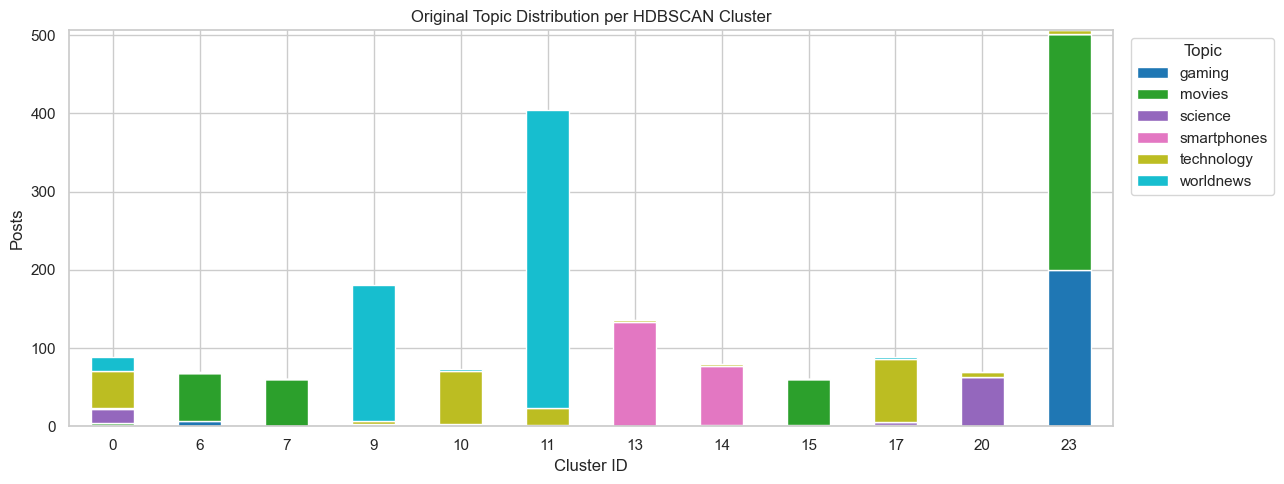

In [9]:
top_clusters = cluster_counts.head(12)["cluster"].tolist()
pivot = (
    df[df["cluster"].isin(top_clusters)]
    .groupby(["cluster", "niche"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", stacked=True, colormap="tab10", ax=ax)
ax.set_title("Original Topic Distribution per HDBSCAN Cluster")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Results/HDBSCAN/hdbscan_topic_distribution.png", bbox_inches="tight")
plt.show()

## 9. Engagement Analytics per Cluster

         Avg Engagement  Median      Total
cluster                                   
11               4374.9   492.5  1767450.0
9                3406.5   527.0   616571.0
23                628.4    68.0   317965.0
17               2593.4    49.5   228215.0
7                2877.3  1461.0   175518.0
0                1838.9   464.5   161827.0
20               2178.9   436.0   150343.0
6                1535.4   210.0   105941.0
10                829.1    33.0    60527.0
15                930.9   617.0    55854.0
14                107.3     7.0     8476.0
13                 23.3     9.0     3167.0


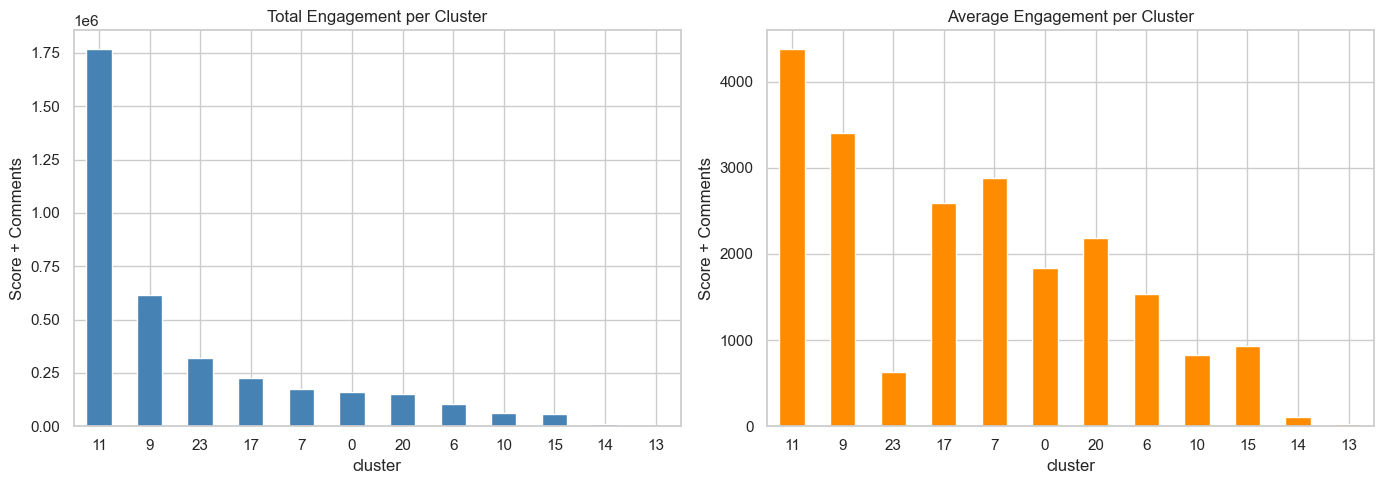

In [10]:
eng_stats = (
    df[df["cluster"].isin(top_clusters)]
    .groupby("cluster")["engagement"]
    .agg(["mean", "median", "sum"])
    .rename(columns={"mean": "Avg Engagement", "median": "Median", "sum": "Total"})
    .sort_values("Total", ascending=False)
)

print(eng_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eng_stats["Total"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Engagement per Cluster")
axes[0].set_ylabel("Score + Comments")
axes[0].tick_params(axis="x", rotation=0)

eng_stats["Avg Engagement"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average Engagement per Cluster")
axes[1].set_ylabel("Score + Comments")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_engagement.png", bbox_inches="tight")
plt.show()

## 10. Cluster Activity Over Time

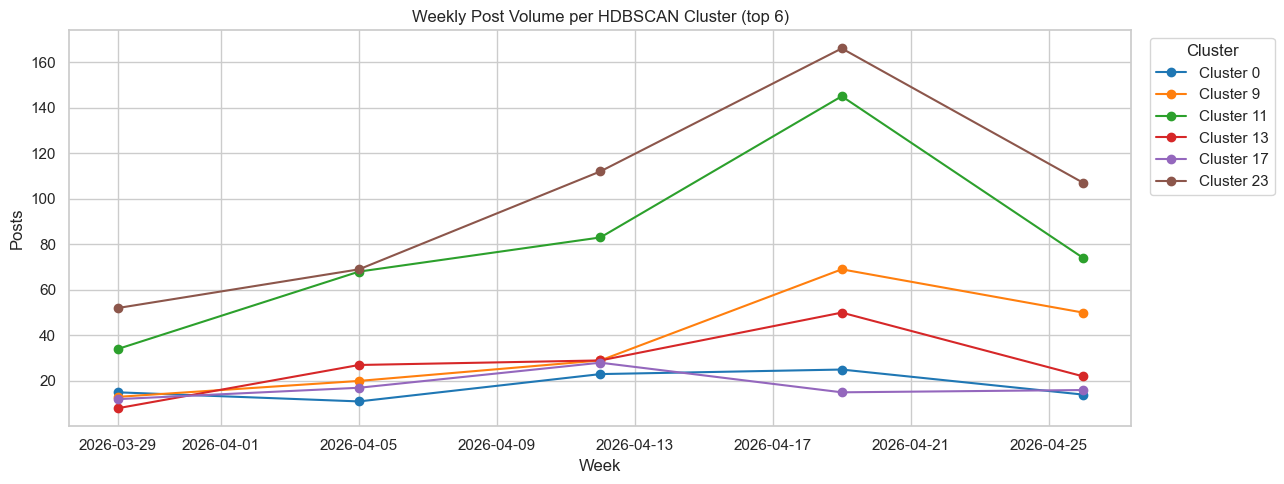

In [14]:
time_df = (
    df[df["cluster"].isin(top_clusters[:6])]
    .groupby([pd.Grouper(key="timestamp_utc", freq="W"), "cluster"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 5))
for cid, grp in time_df.groupby("cluster"):
    ax.plot(grp["timestamp_utc"], grp["count"], marker="o", label=f"Cluster {cid}")

ax.set_title("Weekly Post Volume per HDBSCAN Cluster (top 6)")
ax.set_xlabel("Week")
ax.set_ylabel("Posts")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Results/HDBSCAN/hdbscan_time_series.png", bbox_inches="tight")
plt.show()

## 11. 2D Visualisation (SVD → 2 components)

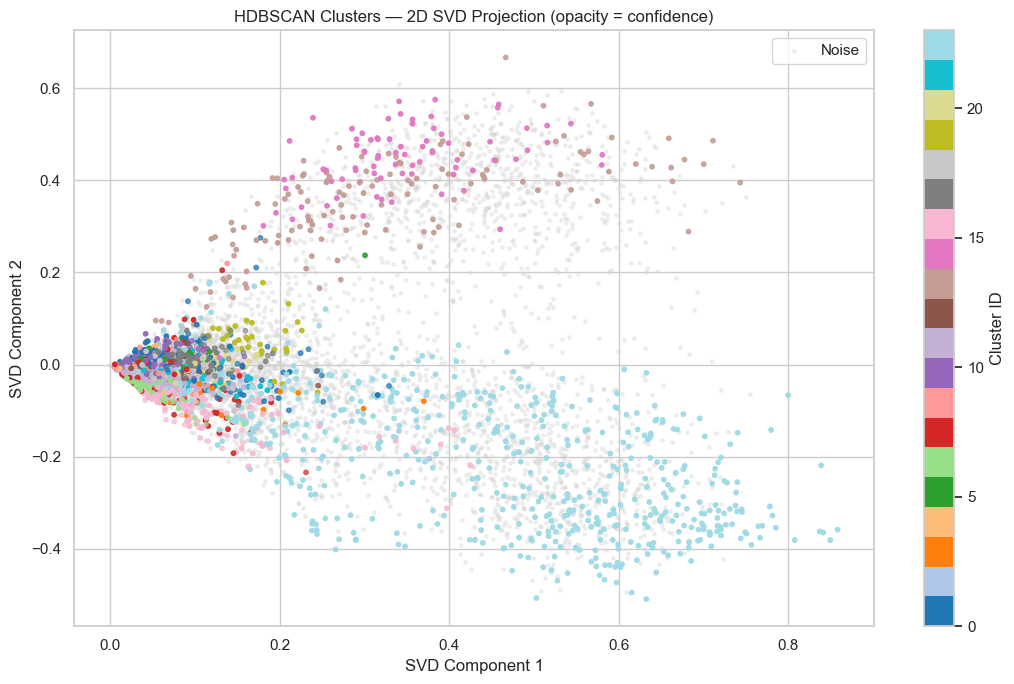

In [15]:
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd2.fit_transform(X_norm)

plot_df = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1],
                         "cluster": labels, "prob": clusterer.probabilities_})

noise_mask   = plot_df["cluster"] == -1
cluster_mask = ~noise_mask

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df.loc[noise_mask, "x"], plot_df.loc[noise_mask, "y"],
           c="lightgrey", s=6, alpha=0.3, label="Noise")

sc = ax.scatter(
    plot_df.loc[cluster_mask, "x"],
    plot_df.loc[cluster_mask, "y"],
    c=plot_df.loc[cluster_mask, "cluster"],
    alpha=plot_df.loc[cluster_mask, "prob"].values * 0.85 + 0.1,
    cmap="tab20", s=10
)
plt.colorbar(sc, ax=ax, label="Cluster ID")
ax.set_title("HDBSCAN Clusters — 2D SVD Projection (opacity = confidence)")
ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.legend()
plt.tight_layout()
plt.savefig("Results/HDBSCAN/hdbscan_2d.png", bbox_inches="tight")
plt.show()

## 12. Summary Table — Top Clusters

In [16]:
summary = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("posts", ascending=False)
    .head(15)
)

summary["avg_engagement"] = summary["avg_engagement"].round(1)
summary["total_engagement"] = summary["total_engagement"].astype(int)

print("\n── DBSCAN Cluster Summary ──")
print(summary.to_string())


── DBSCAN Cluster Summary ──
         posts  avg_engagement  total_engagement dominant_topic                                                                             keywords
cluster                                                                                                                                             
23         506           628.4            317965         movies                                 movie, game, like, movies, just, games, really, time
11         404          4374.9           1767450      worldnews                      iran, hormuz, strait, strait hormuz, trump, war, iran war, says
9          181          3406.5            616571      worldnews                         ukraine, russian, russia, hungary, election, oil, eu, magyar
13         136            23.3              3167    smartphones                               pro, iphone, ultra, 17, s26, iphone 17, pro max, phone
0           88          1838.9            161827     technology           so

## 13. Trend Report

In [17]:
report = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        first_seen=("timestamp_utc", "min"),
        last_seen=("timestamp_utc", "max"),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("total_engagement", ascending=False)
    .reset_index()
)

report["avg_engagement"] = report["avg_engagement"].round(1)
report["total_engagement"] = report["total_engagement"].astype(int)

print("=" * 80)
print("EMERGING TRENDS REPORT")
print("=" * 80)
for _, row in report.iterrows():
    print(f"\n#{int(row['cluster'])} | {row['dominant_topic']}")
    print(f"   Keywords   : {row['keywords']}")
    print(f"   Posts      : {row['posts']}  |  Total Engagement: {row['total_engagement']}  |  Avg: {row['avg_engagement']}")
    print(f"   Active     : {row['first_seen'].date()} → {row['last_seen'].date()}")
print("\n" + "=" * 80)

report.to_csv("Results/DBSCAN/trend_report_dbscan.csv", index=False)

EMERGING TRENDS REPORT

#11 | worldnews
   Keywords   : iran, hormuz, strait, strait hormuz, trump, war, iran war, says
   Posts      : 404  |  Total Engagement: 1767450  |  Avg: 4374.9
   Active     : 2026-03-25 → 2026-04-24

#9 | worldnews
   Keywords   : ukraine, russian, russia, hungary, election, oil, eu, magyar
   Posts      : 181  |  Total Engagement: 616571  |  Avg: 3406.5
   Active     : 2026-03-25 → 2026-04-24

#23 | movies
   Keywords   : movie, game, like, movies, just, games, really, time
   Posts      : 506  |  Total Engagement: 317965  |  Avg: 628.4
   Active     : 2026-03-25 → 2026-04-24

#17 | technology
   Keywords   : ai, startup, generated, ai generated, says, powered, future, revenue
   Posts      : 88  |  Total Engagement: 228215  |  Avg: 2593.4
   Active     : 2026-03-25 → 2026-04-23

#5 | technology
   Keywords   : data, centers, data centers, data center, center, ai, ai data, half
   Posts      : 49  |  Total Engagement: 184151  |  Avg: 3758.2
   Active     : 2